# 05 - Model Evaluation

Neste notebook, avaliamos em profundidade o modelo XGBoost selecionado para o problema de credit scoring.

O objetivo é analisar:
- desempenho global do modelo
- capacidade de separação entre classes
- comportamento do score predito
- impacto do threshold na classificação
- variáveis mais importantes para decisão

In [6]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

## 1. Imports

In [7]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from src.models.evaluate_model import evaluate_model
import joblib

## 2. Caminhos e carregamento dos dados

Carregamos:
- a base final de modelagem
- o artefato salvo do XGBoost
- as métricas geradas pela função de avaliação

In [8]:
PROJECT_ROOT = Path().resolve().parents[0]

data_path = PROJECT_ROOT / "data" / "processed" / "credit_score_features.csv"
artifact_path = PROJECT_ROOT / "models" / "xgboost_artifact.pkl"

df = pd.read_csv(data_path)
metrics = evaluate_model(df, str(artifact_path))

print(df.shape)
df.head()

(100000, 35)


,Customer_ID,Month,Month_Num,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,target,Loan_Type_Count,Has_Min_Payment_Only,Is_Bad_Credit_Mix,Debt_to_Income_Ratio,EMI_to_Income_Ratio,Invested_to_Income_Ratio,Balance_to_Income_Ratio,Delay_x_Inquiries,Utilization_x_Debt
0,CUS_0x1000,January,1,18,Lawyer,30625.94,2706.161667,6,5,27,...,0,2,1,1,0.051032,0.015868,0.090442,0.093463,620,41592.306407
1,CUS_0x1000,February,2,18,Lawyer,30625.94,2706.161667,6,5,27,...,1,2,1,1,0.051032,0.015868,0.065086,0.115123,682,46011.693758
2,CUS_0x1000,March,3,18,Lawyer,30625.94,2706.161667,6,5,27,...,1,2,1,1,0.051032,0.015868,0.040299,0.136215,682,59837.459708
3,CUS_0x1000,April,4,18,Lawyer,30625.94,2706.161667,6,5,27,...,1,2,1,1,0.051032,0.015868,0.032485,0.155115,704,51330.780120
4,CUS_0x1000,May,5,18,Lawyer,30625.94,2706.161667,6,5,27,...,1,2,1,1,0.051032,0.015868,0.070888,0.113016,737,50529.674519


## 3. Métricas principais

Avaliamos o modelo com foco em:
- ROC AUC
- precision, recall e F1-score
- matriz de confusão

In [9]:
print(f"ROC AUC: {metrics['roc_auc']:.4f}")
print("\nClassification Report:\n")
print(pd.DataFrame(metrics["classification_report"]).transpose())

ROC AUC: 0.9036

Classification Report:

              precision    recall  f1-score       support
0              0.919538  0.820399  0.867145   71002.00000
1              0.652089  0.824229  0.728123   28998.00000
accuracy       0.821510  0.821510  0.821510       0.82151
macro avg      0.785813  0.822314  0.797634  100000.00000
weighted avg   0.841983  0.821510  0.826831  100000.00000


## 4. Matriz de confusão

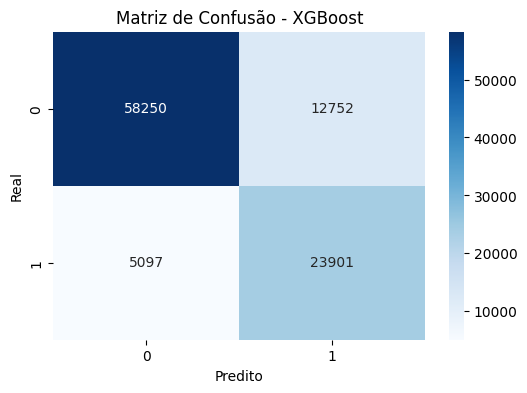

In [10]:
cm = metrics["confusion_matrix"]

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - XGBoost")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## 5. Curva ROC

A curva ROC mostra o trade-off entre a taxa de verdadeiros positivos e a taxa de falsos positivos para diferentes thresholds.

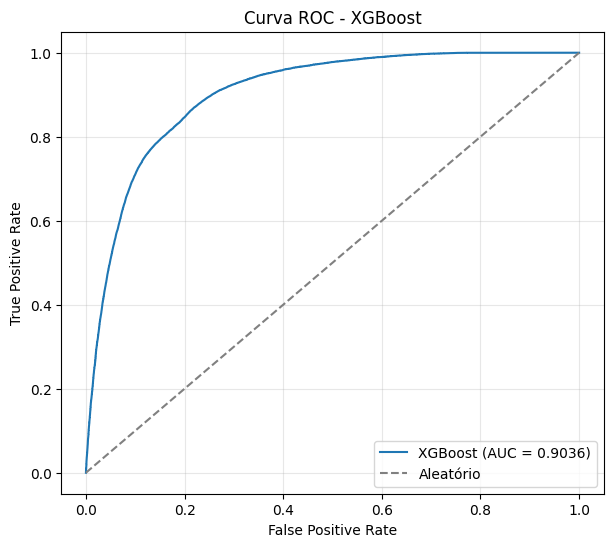

In [11]:
fpr = metrics["fpr"]
tpr = metrics["tpr"]
roc_auc = metrics["roc_auc"]

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - XGBoost")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 6. Gini

O coeficiente de Gini é bastante utilizado em crédito e pode ser obtido a partir da AUC:

\[
Gini = 2 \times AUC - 1
\]

In [12]:
gini = 2 * metrics["roc_auc"] - 1
print(f"Gini: {gini:.4f}")

Gini: 0.8072


## 7. KS Statistic

O KS mede a separação máxima entre as distribuições acumuladas das classes 0 e 1.

In [13]:
ks_values = tpr - fpr
ks = ks_values.max()
ks_idx = np.argmax(ks_values)

print(f"KS: {ks:.4f}")
print(f"Threshold aproximado no KS máximo: {metrics['roc_thresholds'][ks_idx]:.4f}")

KS: 0.6503
Threshold aproximado no KS máximo: 0.3985


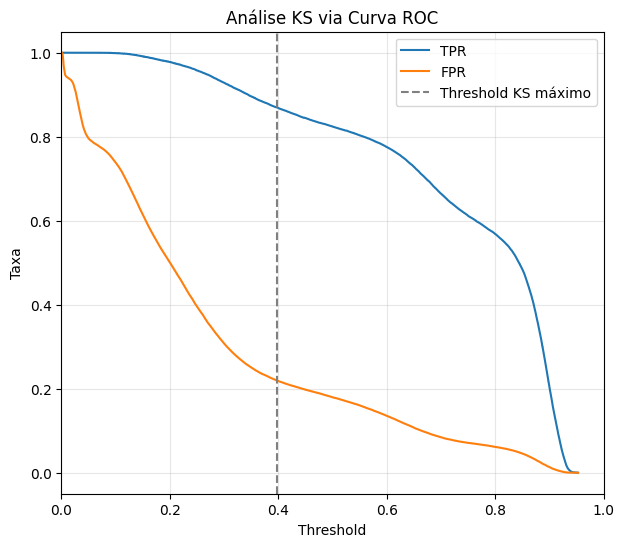

In [14]:
plt.figure(figsize=(7, 6))
plt.plot(metrics["roc_thresholds"], tpr, label="TPR")
plt.plot(metrics["roc_thresholds"], fpr, label="FPR")
plt.axvline(metrics["roc_thresholds"][ks_idx], linestyle="--", color="gray", label="Threshold KS máximo")
plt.xlabel("Threshold")
plt.ylabel("Taxa")
plt.title("Análise KS via Curva ROC")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 1)
plt.show()

## 8. Distribuição dos scores preditos

Aqui observamos como o modelo distribui as probabilidades de inadimplência entre as classes reais.

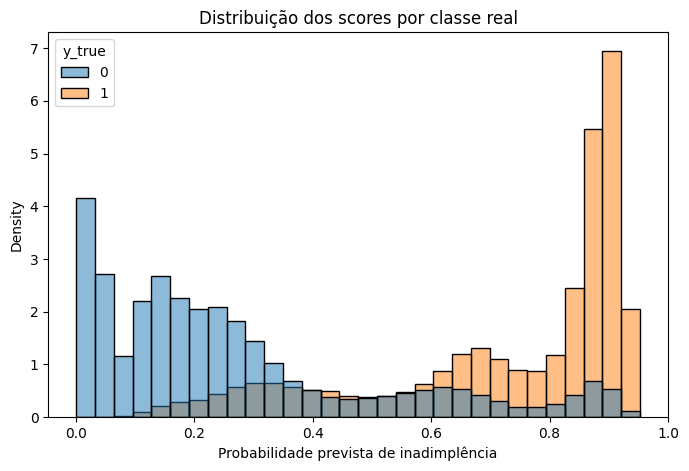

In [15]:
y_true = np.array(metrics["y_true"])
y_proba = np.array(metrics["y_proba"])

df_scores = pd.DataFrame({
    "y_true": y_true,
    "score_default": y_proba
})

plt.figure(figsize=(8, 5))
sns.histplot(data=df_scores, x="score_default", hue="y_true", bins=30, stat="density", common_norm=False)
plt.title("Distribuição dos scores por classe real")
plt.xlabel("Probabilidade prevista de inadimplência")
plt.show()

## 9. Análise de threshold

O modelo produz probabilidades. O threshold converte essa probabilidade em classe predita.

Nesta etapa, analisamos o efeito do threshold sobre precision, recall e F1-score da classe inadimplente.

In [16]:
thresholds = np.linspace(0.1, 0.9, 81)
rows = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    report_t = classification_report(y_true, y_pred_t, output_dict=True, zero_division=0)
    rows.append({
        "threshold": t,
        "precision_1": report_t["1"]["precision"],
        "recall_1": report_t["1"]["recall"],
        "f1_1": report_t["1"]["f1-score"]
    })

threshold_df = pd.DataFrame(rows)
threshold_df.head()

,threshold,precision_1,recall_1,f1_1
0,0.10,0.355765,0.999069,0.524690
1,0.11,0.361562,0.998379,0.530870
2,0.12,0.369216,0.997552,0.538954
3,0.13,0.377856,0.995655,0.547814
4,0.14,0.387126,0.993862,0.557210


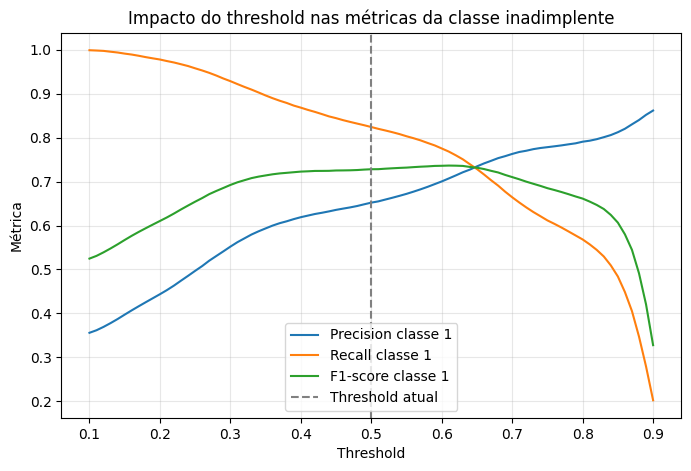

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision_1"], label="Precision classe 1")
plt.plot(threshold_df["threshold"], threshold_df["recall_1"], label="Recall classe 1")
plt.plot(threshold_df["threshold"], threshold_df["f1_1"], label="F1-score classe 1")
plt.axvline(0.5, linestyle="--", color="gray", label="Threshold atual")
plt.title("Impacto do threshold nas métricas da classe inadimplente")
plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Analisando esse gráfico, podemos ver que o pico de F1-Score, não ocorre no Threshold = 0.5, ou seja, uma melhoria aqui também, seria aumentar um pouco o threshold, para aproximadamente 0.65. Nesse ponto, teria basicamente o pico de f1-score, e é onde teriamos uma leve melhoria no modelo

## 10. Decis por faixa de score

Segmentamos os scores em faixas para interpretar melhor o comportamento do modelo.

In [18]:
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

df_scores["score_band"] = pd.cut(df_scores["score_default"], bins=bins, labels=labels, include_lowest=True)

band_summary = (
    df_scores.groupby("score_band", observed=False)
    .agg(
        qtd=("score_default", "size"),
        inadimplentes_reais=("y_true", "sum"),
        taxa_real_inadimplencia=("y_true", "mean"),
        score_medio=("score_default", "mean")
    )
    .reset_index()
)

band_summary

,score_band,qtd,inadimplentes_reais,taxa_real_inadimplencia,score_medio
0,0.0-0.2,36071,640,0.017743,0.091273
1,0.2-0.4,23247,3178,0.136706,0.280972
2,0.4-0.6,8577,2695,0.314212,0.504324
3,0.6-0.8,11268,6007,0.533103,0.688220
4,0.8-1.0,20837,16478,0.790805,0.882083


## 11. Importância das variáveis

Carregamos o artefato salvo e extraímos a importância das variáveis do modelo.

In [19]:
artifact = joblib.load(artifact_path)
model = artifact["model"]
feature_columns = artifact["feature_columns"]

feat_imp = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
42,Credit_Mix_Bad,0.212290
12,Outstanding_Debt,0.142024
20,Is_Bad_Credit_Mix,0.075720
44,Credit_Mix_Standard,0.049782
6,Interest_Rate,0.049519
43,Credit_Mix_Good,0.038230
26,Utilization_x_Debt,0.036695
8,Delay_from_due_date,0.029822
11,Num_Credit_Inquiries,0.022674
5,Num_Credit_Card,0.022435


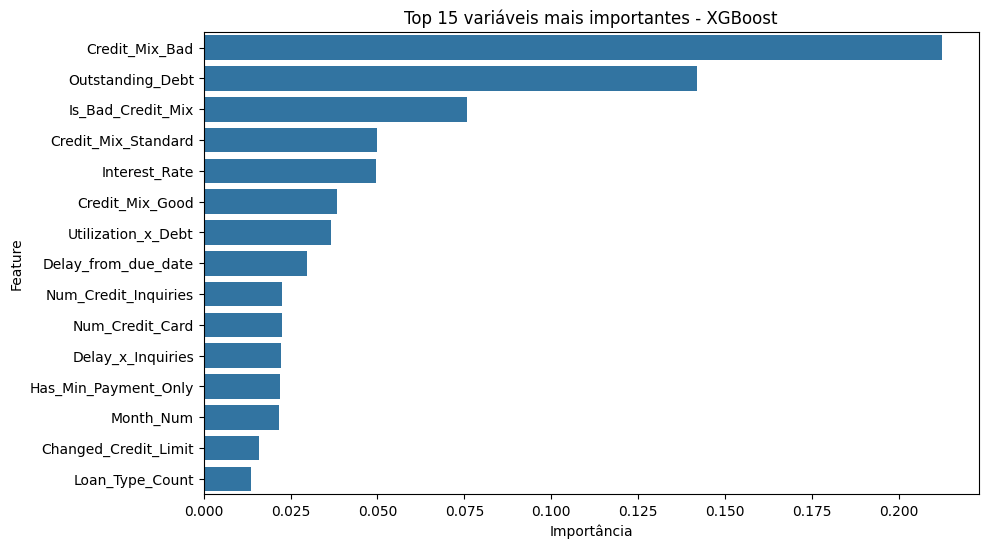

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(15), x="importance", y="feature")
plt.title("Top 15 variáveis mais importantes - XGBoost")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

In [26]:
from src.models.evaluate_model import evaluate_model
import json
metrics = evaluate_model(df, "../models/xgboost_artifact.pkl")

In [31]:
from pprint import pprint
pprint(metrics)

{'classification_report': {'0': {'f1-score': 0.8671445265688617,
                                 'precision': 0.9195384153945727,
                                 'recall': 0.8203994253682995,
                                 'support': 71002.0},
                           '1': {'f1-score': 0.7281229531918783,
                                 'precision': 0.6520885057157668,
                                 'recall': 0.824229257190151,
                                 'support': 28998.0},
                           'accuracy': 0.82151,
                           'macro avg': {'f1-score': 0.7976337398803699,
                                         'precision': 0.7858134605551698,
                                         'recall': 0.8223143412792253,
                                         'support': 100000.0},
                           'weighted avg': {'f1-score': 0.826831050721004,
                                            'precision': 0.8419832905859126,
                        

Salvando as métricas em output/metrics

In [32]:
import json
from pathlib import Path

def make_json_serializable(metrics):
    serializable = {}

    for k, v in metrics.items():
        if hasattr(v, "tolist"):
            serializable[k] = v.tolist()
        elif isinstance(v, dict):
            serializable[k] = v
        else:
            serializable[k] = v

    return serializable

In [34]:
output_path = project_root / "outputs" / "metrics.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

metrics_json = make_json_serializable(metrics)

with open(output_path, "w") as f:
    json.dump(metrics_json, f, indent=4)

## 12. Conclusão

O XGBoost apresentou forte capacidade de separação entre classes, evidenciada por uma AUC elevada.

Além disso, a análise de KS, Gini, distribuição dos scores e sensibilidade ao threshold mostra que o modelo:
- diferencia bem clientes com maior e menor risco
- permite ajuste fino do ponto de corte conforme a estratégia de negócio
- oferece boa interpretabilidade relativa via importância das variáveis

Com isso, o XGBoost se mostra um modelo adequado para o problema de credit scoring neste projeto.